In [31]:
from sklearn.linear_model import LinearRegression

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

Datensatz einlesen

In [3]:
df = pd.read_csv('Data/employees.csv')
df.head()

,EmployeeNumber,Surname,GivenName,Gender,City,JobTitle,DepartmentName,StoreLocation,Division,Age,LengthService,AbsentHours,BusinessUnit
0,1,Gutierrez,Molly,F,Burnaby,Baker,Bakery,Burnaby,Stores,32.028816,6.018478,36.577306,Stores
1,2,Hardwick,Stephen,M,Courtenay,Baker,Bakery,Nanaimo,Stores,40.320902,5.532445,30.165072,Stores
2,3,Delgado,Chester,M,Richmond,Baker,Bakery,Richmond,Stores,48.822047,4.389973,83.807798,Stores
3,4,Simon,Irene,F,Victoria,Baker,Bakery,Victoria,Stores,44.599357,3.081736,70.020165,Stores
4,5,Delvalle,Edward,M,New Westminster,Baker,Bakery,New Westminster,Stores,35.697876,3.619091,0.000000,Stores


In [4]:
df = df[df.AbsentHours != 0]
print(df.head())

   EmployeeNumber    Surname GivenName Gender       City JobTitle  \
0               1  Gutierrez     Molly      F    Burnaby    Baker   
1               2   Hardwick   Stephen      M  Courtenay    Baker   
2               3    Delgado   Chester      M   Richmond    Baker   
3               4      Simon     Irene      F   Victoria    Baker   
5               6      Jones     Ernie      M   Richmond    Baker   

  DepartmentName StoreLocation Division        Age  LengthService  \
0         Bakery       Burnaby   Stores  32.028816       6.018478   
1         Bakery       Nanaimo   Stores  40.320902       5.532445   
2         Bakery      Richmond   Stores  48.822047       4.389973   
3         Bakery      Victoria   Stores  44.599357       3.081736   
5         Bakery      Richmond   Stores  48.440311       2.717692   

   AbsentHours BusinessUnit  
0    36.577306       Stores  
1    30.165072       Stores  
2    83.807798       Stores  
3    70.020165       Stores  
5    81.830079      

# Absenz vs. anz. Jahre

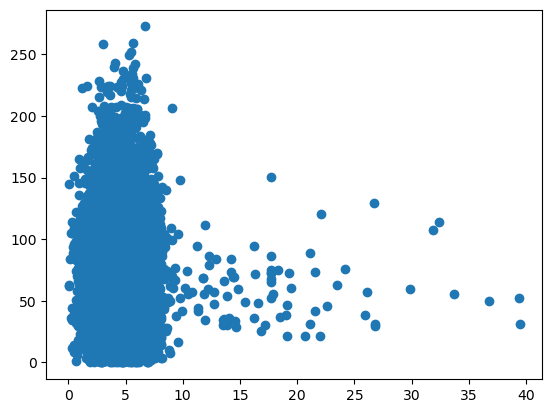

In [23]:
plt.scatter(y=df['AbsentHours'], x=df['LengthService'])
plt.show()

In [24]:
absenzen = df['AbsentHours'].values.reshape(-1,1)
jahre = df['LengthService'].values.reshape(-1,1)

In [53]:
model=LinearRegression()
model.fit(jahre, absenzen)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [54]:
#Residuen berechnen
r_sq = model.score(jahre, absenzen)
print(r_sq)

print(f"intercept: {model.intercept_}")
print(f"slope: {model.coef_}")

0.0005010210095048873
intercept: [74.99104238]
slope: [[-0.46065175]]


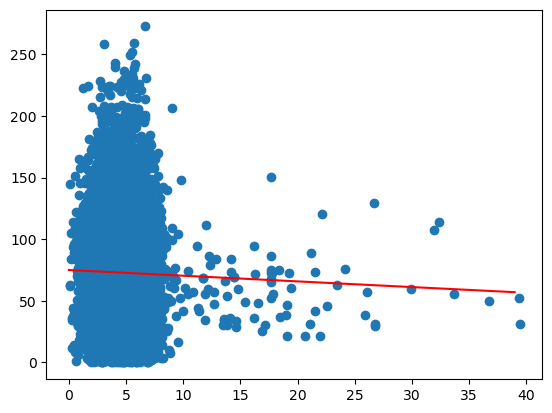

In [63]:
#Lineare Regression
x_new=np.arange(40).reshape(-1,1)
y_new=model.predict(x_new)
plt.scatter(y=absenzen, x=jahre)
plt.plot(x_new, y_new, color='red')
plt.show()

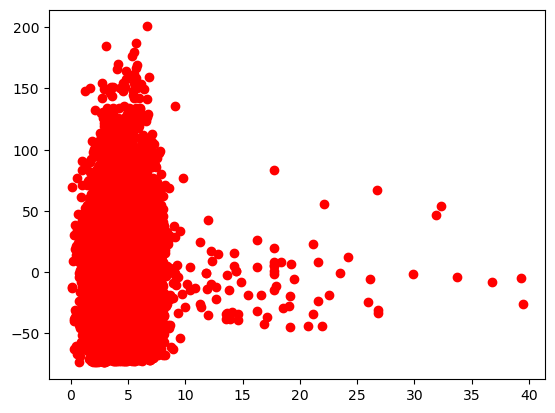

In [65]:
#Residuen
y_pred = model.predict(jahre)
resid = absenzen - y_pred
plt.plot(jahre, resid,'o', color='red')


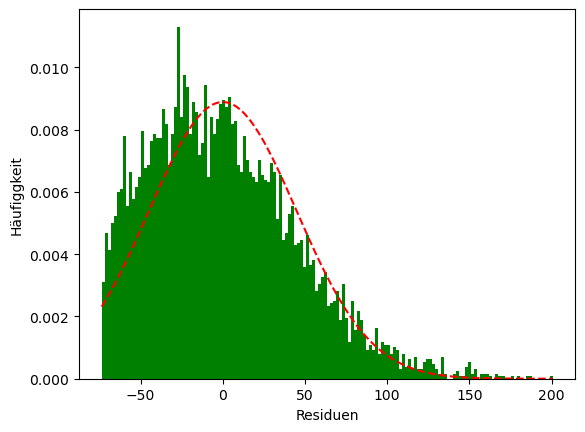

In [66]:
#Verteilung checken

from scipy.stats import norm

n, bins, patches = plt.hist(resid, bins=150, facecolor='green', stacked=True, density=True)
plt.xlabel('Residuen')
plt.ylabel('Häufiggkeit')
mu = np.average(resid)
sigma = np.std(resid)
y=norm.pdf(bins, mu, sigma)
plt.plot(bins, y, 'r--')
plt.show()


# Absenz vs. Alter

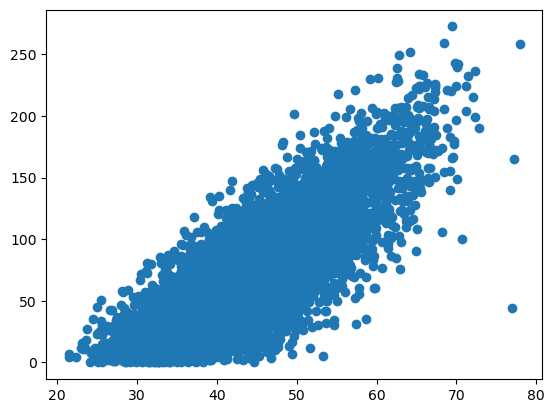

In [67]:
plt.scatter(y=df['AbsentHours'], x=df['Age'])
plt.show()

In [68]:
absenzen = df['AbsentHours'].values.reshape(-1,1)
alter = df['Age'].values.reshape(-1,1)

In [69]:
model1 = LinearRegression()
model1.fit(alter, absenzen)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [70]:
r_sq1 = model.score(absenzen, alter)
print(r_sq1)
print(f"intercept: {model1.intercept_}")
print(f"slope: {model1.coef_}")

-10.152460751728006
intercept: [-118.51170857]
slope: [[4.30605265]]


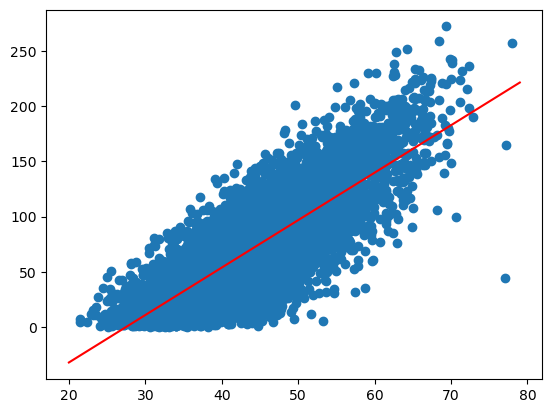

In [72]:
x_new = np.arange(60).reshape((-1,1))+20
y_new = model1.predict(x_new)
plt.scatter(y=absenzen, x=alter)
plt.plot(x_new, y_new, color='red')
plt.show()

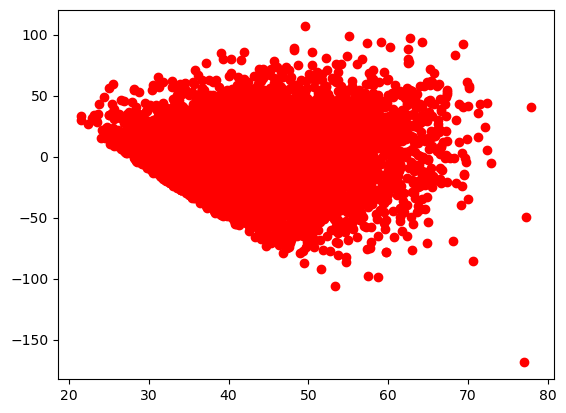

In [75]:
#Residuen
y_pred = model1.predict(alter)
resid = absenzen - y_pred
plt.plot(alter, resid,'o', color='red')

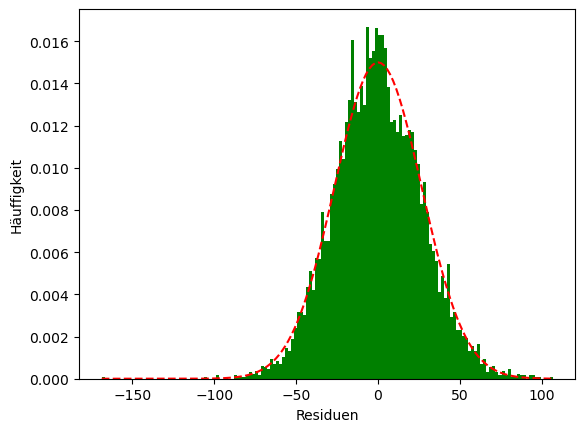

In [74]:
n, bins, patches = plt.hist(resid, bins=150, facecolor='green', stacked=True, density=True)
plt.xlabel('Residuen')
plt.ylabel('Häuffigkeit')
mu = np.average(resid)
sigma = np.std(resid)
y=norm.pdf(bins, mu, sigma)
plt.plot(bins, y, 'r--')
plt.show()